In [25]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [26]:
ctrl = pd.read_csv(Path("/mnt/1248/open/finley/hydrocephalus/Ctrl/data.csv"))
hydro_1 = pd.read_csv(Path("/mnt/1248/open/finley/hydrocephalus/Hydro_1/data.csv"))

In [27]:
ctrl["group"] = "Control"
hydro_1["group"] = "Hydrocephalus"
df = pd.concat([ctrl, hydro_1], ignore_index=True)

df.groupby("group")["fa"].describe()


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
Control,29.0,0.572273,0.069733,0.418431,0.510478,0.591657,0.618205,0.689392
Hydrocephalus,38.0,0.429748,0.051916,0.255351,0.402386,0.428816,0.457361,0.543832


In [23]:
stat, p = stats.mannwhitneyu(ctrl["fa"], hydro_1["fa"], alternative="two-sided")
print(f"Mann-Whitney U = {stat:.2f}, p = {p:.4f}")

Mann-Whitney U = 1035.00, p = 0.0000


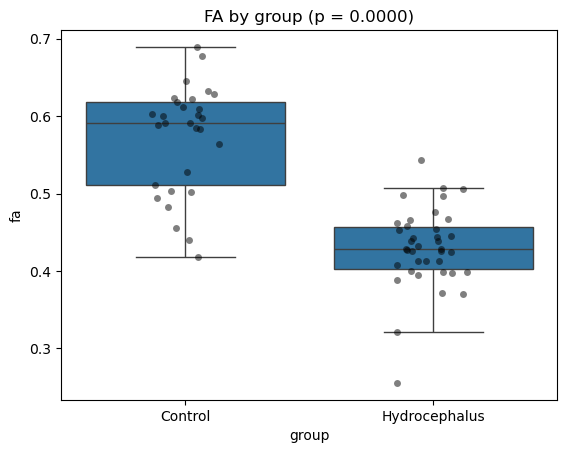

In [24]:
sns.boxplot(data=df, x="group", y="fa", showfliers=False)
sns.stripplot(data=df, x="group", y="fa", color="black", alpha=0.5, jitter=0.15)
plt.title(f"FA by group (p = {p:.4f})")
plt.show()